# Binary Classification using Bayesian Classifiers

---

All three models are **Bayesian generative classifiers**. This means:

* They model the **joint distribution** ( p(x, y) )
* Specifically, they estimate:

  * **Class priors** ( p(y = k) )
  * **Class-conditional densities** ( p(x \mid y = k) )
* Classification is performed using **Bayes’ decision rule**

- For GNB, LDA, QDA, training means:
  “Estimate the parameters of the probability distribution that generated the data.”

There is no loss function to minimize numerically.

**Bayes' Rule:**


$P(y \mid x) = \frac{P(x \mid y) P(y)}{P(x)}$

* Prior: $P(y)$
* Likelihood: $P(x \mid y$)
* Posterior: $P(y \mid x$)
* normalization constant: $p(x) = \sum_j p(x \mid y=j)p(y=j)$


---

### Classification Rule

$\hat{y} = \arg\max_k ; p(y = k \mid x)$

Since $p(x)$ does not depend on the class:

$\hat{y} = \arg\max_k ; p(x \mid y=k),p(y=k)$

This rule is common to **GNB, LDA, and QDA**.

---

#### All three models assume:

$p(x \mid y=k) = \mathcal{N}(x \mid \mu_k, \Sigma_k)$

The multivariate Gaussian density is:

$p(x \mid y=k)$


$\frac{1}{(2\pi)^{d/2} |\Sigma_k|^{1/2}}
\exp\left(
-\frac{1}{2}(x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k)
\right)$

Where:

* $\mu_k \in \mathbb{R}^d$: class mean vector
* $\Sigma_k \in \mathbb{R}^{d \times d}$: class covariance matrix


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Understanding The Data

In [4]:
file_path = "data/Breast Cancer Wisconsin/wdbc.data"

columns = ["id", "diagnosis"] + [f"feature_{i}" for i in range(30)]

data = pd.read_csv(
    file_path,
    header=None,
    names=columns
)

print(data.shape)
print(data.head())


(569, 32)
         id diagnosis  feature_0  feature_1  feature_2  feature_3  feature_4  \
0    842302         M      17.99      10.38     122.80     1001.0    0.11840   
1    842517         M      20.57      17.77     132.90     1326.0    0.08474   
2  84300903         M      19.69      21.25     130.00     1203.0    0.10960   
3  84348301         M      11.42      20.38      77.58      386.1    0.14250   
4  84358402         M      20.29      14.34     135.10     1297.0    0.10030   

   feature_5  feature_6  feature_7  ...  feature_20  feature_21  feature_22  \
0    0.27760     0.3001    0.14710  ...       25.38       17.33      184.60   
1    0.07864     0.0869    0.07017  ...       24.99       23.41      158.80   
2    0.15990     0.1974    0.12790  ...       23.57       25.53      152.50   
3    0.28390     0.2414    0.10520  ...       14.91       26.50       98.87   
4    0.13280     0.1980    0.10430  ...       22.54       16.67      152.20   

   feature_23  feature_24  feature

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          569 non-null    int64  
 1   diagnosis   569 non-null    object 
 2   feature_0   569 non-null    float64
 3   feature_1   569 non-null    float64
 4   feature_2   569 non-null    float64
 5   feature_3   569 non-null    float64
 6   feature_4   569 non-null    float64
 7   feature_5   569 non-null    float64
 8   feature_6   569 non-null    float64
 9   feature_7   569 non-null    float64
 10  feature_8   569 non-null    float64
 11  feature_9   569 non-null    float64
 12  feature_10  569 non-null    float64
 13  feature_11  569 non-null    float64
 14  feature_12  569 non-null    float64
 15  feature_13  569 non-null    float64
 16  feature_14  569 non-null    float64
 17  feature_15  569 non-null    float64
 18  feature_16  569 non-null    float64
 19  feature_17  569 non-null    f

In [6]:
class_counts = data["diagnosis"].value_counts()
class_proportions = class_counts / len(data)

print(class_counts)
print(class_proportions)


diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    0.627417
M    0.372583
Name: count, dtype: float64


Benign ≈ 62%

Malignant ≈ 38%

Mild imbalance → priors matter in Bayesian classifiers

GNB/LDA/QDA incorporate priors explicitly, so imbalance is handled naturally

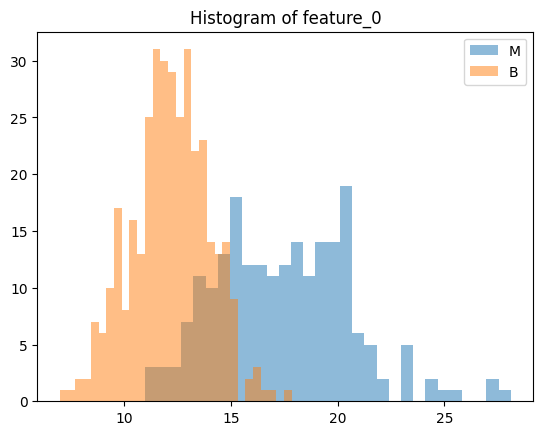

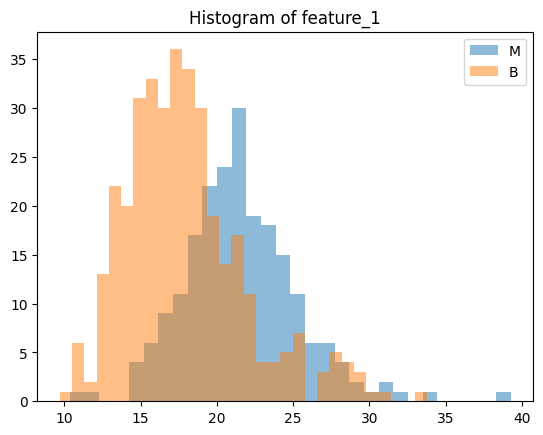

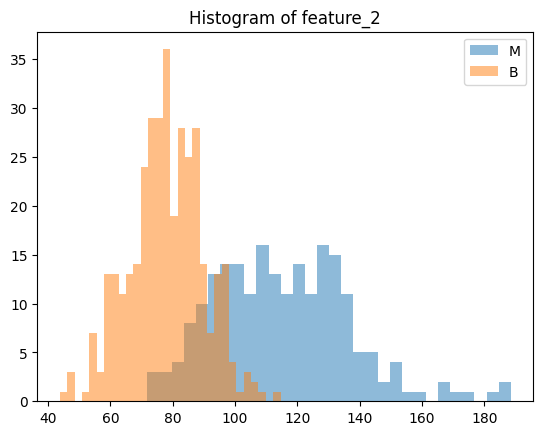

In [8]:
features_to_plot = ["feature_0", "feature_1", "feature_2"]

for f in features_to_plot:
    plt.figure()
    for label in ["M", "B"]:
        subset = data[data["diagnosis"] == label][f]
        plt.hist(subset, bins=30, alpha=0.5, label=label)
    plt.title(f"Histogram of {f}")
    plt.legend()
    plt.show()


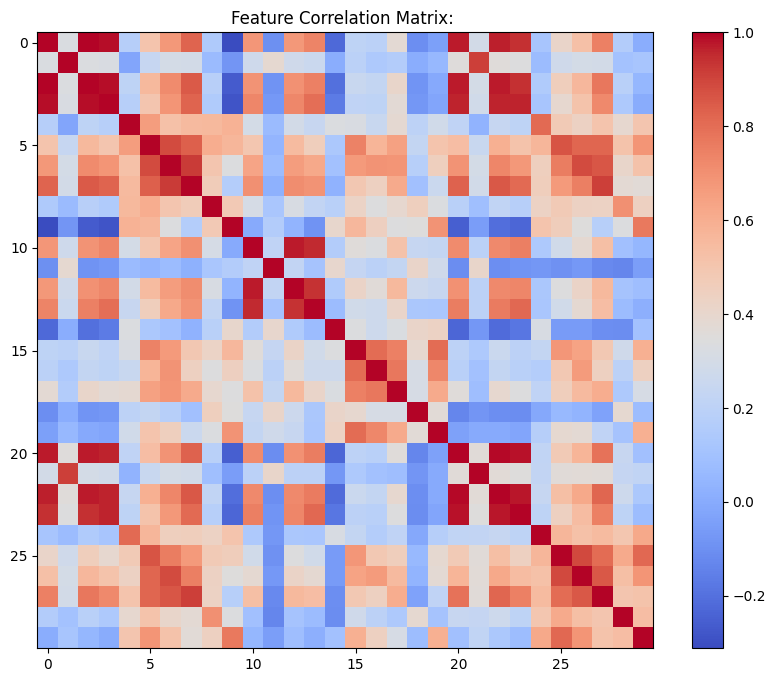

In [10]:
X_features = data.iloc[:, 2:]
corr = X_features.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.title("Feature Correlation Matrix: ")
plt.show()

In [11]:
corr_values = corr.abs()
np.fill_diagonal(corr_values.values, 0)

top_pairs = (
    corr_values.stack()
    .sort_values(ascending=False)
    .head(3)
)

print(top_pairs)


feature_2   feature_0     0.997855
feature_0   feature_2     0.997855
feature_20  feature_22    0.993708
dtype: float64


- Highly correlated features violate Naïve Bayes independence

- LDA/QDA explicitly model correlations

- QDA benefits most when correlations differ by class

---

We can ignore normalization here, _why_? 


$\arg\max_y P(y \mid x) = \arg\max_y P(x \mid y) P(y)$


Since $P(x)$ is constant across classes.

---

So let's investigate the model parameters ... 

| Model | Means                  | Covariance          | Priors |
| ----- | ---------------------- | ------------------- | ------ |
| GNB   | Per-feature, per-class | Diagonal            | Yes    |
| LDA   | Per-class              | Shared full         | Yes    |
| QDA   | Per-class              | Class-specific full | Yes    |

QDA has most parameters → needs more data


### Data Split

In [ ]:
X = data.iloc[:, 2:].values
y = data["diagnosis"].map({"B": 0, "M": 1}).values

np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx, test_idx = indices[:split], indices[split:] # 80% for Training, 20% For testing

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


In [13]:
def estimate_gnb(X, y):
    """Gaussian Naïve Bayes"""
    classes = np.unique(y)
    priors = {}
    means = {}
    variances = {}

    for c in classes:
        Xc = X[y == c]
        priors[c] = len(Xc) / len(X)
        means[c] = Xc.mean(axis=0)
        variances[c] = Xc.var(axis=0)

    return priors, means, variances


### Linear Discriminant Analysis (LDA)

1. Class-conditional distributions are Gaussian
2. **All classes share the same covariance matrix**:

$
\Sigma_0 = \Sigma_1 = \Sigma
$

This is the defining assumption of LDA.

---

#### Likelihood

$p(x∣y=k)=N(x∣μk​,Σ)$

---

#### Discriminant Function

Taking the log posterior and removing class-independent terms:

$δk​(x)=xTΣ−1μk​−21​μkT​Σ−1μk​+logp(y=k)$
=k)$

---

#### Decision Rule

$
\hat{y} = \arg\max_k \delta_k(x)
$

This function is **linear in ( x )**.

---

In [14]:
def estimate_lda(X, y):
    """LDA"""
    classes = np.unique(y)
    priors = {}
    means = {}

    for c in classes:
        Xc = X[y == c]
        priors[c] = len(Xc) / len(X)
        means[c] = Xc.mean(axis=0)

    # pooled covariance
    cov = np.cov(X.T, bias=False)
    return priors, means, cov


### Quadratic Discriminant Analysis (QDA)

#### 5.1 Assumptions

1. Gaussian class-conditional distributions
2. **Each class has its own covariance matrix**:

$
\Sigma_0 \neq \Sigma_1
$

This is the most general Gaussian classifier.

---

#### Likelihood

$p(x∣y=k)=N(x∣μk​,Σk​)$

---

#### Discriminant Function

$δk​(x)=−21​log∣Σk​∣−21​(x−μk​)TΣk−1​(x−μk​)+logp(y=k)$

---

#### Decision Rule

$
y^​=argkmax​δk​(x)
$

The quadratic form produces **non-linear decision boundaries**.

---


In [15]:
def estimate_qda(X, y):
    """QDA"""
    classes = np.unique(y)
    priors = {}
    means = {}
    covs = {}

    for c in classes:
        Xc = X[y == c]
        priors[c] = len(Xc) / len(X)
        means[c] = Xc.mean(axis=0)
        covs[c] = np.cov(Xc.T, bias=False)

    return priors, means, covs


## Predictions

In [16]:
def predict_gnb(X, priors, means, variances):
    preds = []
    for x in X:
        scores = {}
        for c in priors:
            log_likelihood = -0.5 * np.sum(
                np.log(2 * np.pi * variances[c]) +
                ((x - means[c]) ** 2) / variances[c]
            )
            scores[c] = np.log(priors[c]) + log_likelihood
        preds.append(max(scores, key=scores.get))
    return np.array(preds)


In [17]:
def predict_lda(X, priors, means, cov):
    inv_cov = np.linalg.inv(cov)
    preds = []

    for x in X:
        scores = {}
        for c in priors:
            diff = x - means[c]
            scores[c] = (
                np.log(priors[c]) -
                0.5 * diff @ inv_cov @ diff
            )
        preds.append(max(scores, key=scores.get))
    return np.array(preds)


In [18]:
def predict_qda(X, priors, means, covs):
    preds = []

    for x in X:
        scores = {}
        for c in priors:
            cov = covs[c]
            inv_cov = np.linalg.inv(cov)
            diff = x - means[c]
            scores[c] = (
                np.log(priors[c]) -
                0.5 * np.log(np.linalg.det(cov)) -
                0.5 * diff @ inv_cov @ diff
            )
        preds.append(max(scores, key=scores.get))
    return np.array(preds)


## Training 

In [19]:
gnb_params = estimate_gnb(X_train, y_train)
lda_params = estimate_lda(X_train, y_train)
qda_params = estimate_qda(X_train, y_train)

y_pred_gnb = predict_gnb(X_test, *gnb_params)
y_pred_lda = predict_lda(X_test, *lda_params)
y_pred_qda = predict_qda(X_test, *qda_params)


In [20]:
cov = np.cov(X_train.T)
rank = np.linalg.matrix_rank(cov)
eigenvalues = np.linalg.eigvals(cov)
condition_number = np.linalg.cond(cov)

print("Rank:", rank)
print("Min eigenvalue:", eigenvalues.min())
print("Max eigenvalue:", eigenvalues.max())
print("Condition number:", condition_number)


Rank: 30
Min eigenvalue: 5.512684863030445e-07
Max eigenvalue: 419566.84569622774
Condition number: 761093471004.627


- Full-rank ≠ numerically stable

- Large condition number → unstable inversion

- QDA more affected than LDA

In [21]:
variances = X_train.var(axis=0)
low_variance_idx = np.argsort(variances)[:5]

print("Lowest variance features:", low_variance_idx)


Lowest variance features: [19 14 17  9 18]


In [22]:
threshold = np.percentile(variances, 10)
selected_features = variances > threshold

X_train_red = X_train[:, selected_features]
X_test_red = X_test[:, selected_features]

cov_red = np.cov(X_train_red.T)

print("Original cond:", np.linalg.cond(cov))
print("Reduced cond:", np.linalg.cond(cov_red))


Original cond: 761093471004.627
Reduced cond: 148783149199.30542


In [23]:
lda_params_red = estimate_lda(X_train_red, y_train)
qda_params_red = estimate_qda(X_train_red, y_train)

y_pred_lda_red = predict_lda(X_test_red, *lda_params_red)
y_pred_qda_red = predict_qda(X_test_red, *qda_params_red)


In [24]:
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

def metrics(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
    acc = (TP + TN) / len(y_true)
    prec = TP / (TP + FP)
    rec = TP / (TP + FN)
    f1 = 2 * prec * rec / (prec + rec)
    return acc, prec, rec, f1


In [25]:
d = X.shape[1]

lda_params_count = 2*d + d*(d+1)//2
qda_params_count = 2*d + 2*(d*(d+1)//2)

print("LDA parameters:", lda_params_count)
print("QDA parameters:", qda_params_count)


LDA parameters: 525
QDA parameters: 990


## Observations

- LDA: best bias–variance tradeoff

- QDA: flexible but unstable in high dimensions

- Variance elimination improves conditioning but does not solve correlation issues

- GNB is a strong baseline despite violated independence



| Property                | GNB                      | LDA         | QDA                 |
| ----------------------- | ------------------------ | ----------- | ------------------- |
| Independence assumption | Yes                      | No          | No                  |
| Covariance              | Diagonal                 | Shared full | Class-specific full |
| Boundary                | Quadratic (axis-aligned) | Linear      | Quadratic           |
| Flexibility             | Low                      | Medium      | High                |
| Overfitting risk        | Low                      | Medium      | High                |
| Data requirement        | Low                      | Medium      | High                |
